# Batch Size Sweep Analysis — UNet2D on ISIC 2017

**Goal:** Identify the optimal training batch size for a 2D U-Net on the ISIC 2017
dermoscopic segmentation dataset, on a dual-T4 GPU target, by comparing per-GPU
training throughput across two sweeps (with- and without-augmentation).

**Method (Google Deep Learning Tuning Playbook):** Batch size is *not* a model-quality
hyperparameter. The chosen batch size is the **largest one that still yields a
near-proportional throughput increase** — i.e. just before the critical batch size
where linear scaling breaks down.


## Section 0 — Design of Experiment & Motivation

### Why batch size governs training speed, not model quality
Shallue et al. (2018) and the Tuning Playbook show that, with re-tuned optimizer
hyperparameters and a sufficient step budget, any batch size can in principle reach
the same final validation performance. Batch size therefore is not a knob for model
quality — it is a knob for *training speed*. Selecting it is a pure throughput
optimisation problem on the target hardware.

### What "perfect scaling" means
In the linear-scaling regime, doubling the batch size doubles `samples_per_sec`
(equivalently: time-per-step stays constant while the per-step work doubles). This
holds while the GPU is the bottleneck and the data pipeline can keep up.

### Why there is a critical batch size
Beyond some batch size, scaling breaks down because (i) the data pipeline (DataLoader
/ disk I/O / augmentation CPU work) becomes the bottleneck, (ii) GPU memory bandwidth
saturates, or (iii) per-GPU compute saturates and additional samples sit idle in
queues. The optimal batch size is the **largest one before this break** — going
larger spends memory without speed gains.

### Why augmentations are tested separately
Training-time augmentations (flips, rotations, colour jitter) add CPU pre-processing
cost per sample. This can shift the bottleneck from GPU to DataLoader/CPU, and may
move the critical batch size to a smaller value than in the no-augmentation case. We
therefore run both sweeps and recommend the more conservative result if they disagree.

### Why LR was scaled linearly with batch size, and why it does not affect the conclusion
`SkiNet/Utils/mlops/optuna_utils.py::scale_lr()` applies the linear-scaling rule
anchored at bs=4, lr=3e-4: bs=8 → 6e-4, bs=16 → 1.2e-3, …, bs=128 → 9.6e-3. The
Tuning Playbook warns that optimizer hyperparameters interact strongly with batch
size and must be *re-tuned independently*; linear scaling is only a heuristic.
Crucially, the selection criterion here (`perf/samples_per_sec`) depends purely on
compute and I/O scheduling and is **independent of the LR value**, provided training
does not diverge. Section 5 exists solely to verify that no run diverged from an
over-scaled LR. Once a batch size is fixed, all optimizer hyperparameters will be
re-tuned from scratch in the subsequent Optuna HPO study; the scaled LRs used here
are not carried forward.

### Why these sweep runs used a single GPU
These runs measure raw per-GPU throughput (`fit/devices: 1`). Production training
will use Distributed Data Parallel (DDP) across 2× T4. In DDP each GPU processes its
own `batch_size`, so the effective global batch size is `bs × 2`. The recommendation
section discusses this implication.


## Implementation checklist

1. **Setup & load** both MLflow SQLite DBs; build tidy step-level DataFrames keyed
   by `(experiment, batch_size, step)`.
2. **Mark outliers** in `is_outlier` (do not drop): step==0, epoch-last
   (`n*spe - 1`), epoch-first (`n*spe`), then a per-run IQR catch-all.
3. **Outlier audit** (Section 2): per-batch-size scatter of `samples_per_sec` and
   `time_per_step_ms` with outliers highlighted; summary table.
4. **Throughput analysis** (Section 3): median throughput vs bs with perfect-scaling
   reference, scaling efficiency, time-per-step, per-run stability bands.
5. **GPU utilisation & memory** (Section 4): median utilisation and allocated memory
   per bs; DDP feasibility flag.
6. **Loss convergence sanity check** (Section 5).
7. **Recommendation** (Section 6) & **conclusion** (Section 7).

If either DB cannot be opened, downstream cells fall back to a placeholder DataFrame
with the exact required schema so every cell still executes.


## Section 1 — Setup & Data Loading

We connect to each MLflow SQLite DB, list active runs, read `batch_size` from
`params`, and pull the step-level metric series we need. The output is one tidy
long-format DataFrame per experiment.


In [1]:
from __future__ import annotations

import sqlite3
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats  # noqa: F401  (kept for downstream stats use)

sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["figure.dpi"] = 110

# --- Paths --------------------------------------------------------------------
# Notebook lives at: repos/SkiNet/analysis_results/<this notebook>.ipynb
# DBs live at:       repos/SkiNet/<*.db>
PROJECT_ROOT = Path.cwd().resolve()
# Try common locations: cwd, parent (when run from analysis_results/), and absolute.
CANDIDATES = [
    PROJECT_ROOT,
    PROJECT_ROOT.parent,
    Path("/teamspace/studios/this_studio/repos/SkiNet"),
]

DB_FILES = {
    "no_aug":   "mlflow-the-batch-size-sweep-experiment.db",
    "with_aug": "mlflow-the-batch-size-sweep-experiment-augm.db",
}

def find_db(name: str) -> Optional[Path]:
    for base in CANDIDATES:
        p = base / name
        if p.exists():
            return p
    return None

DB_PATHS = {label: find_db(fname) for label, fname in DB_FILES.items()}
for label, p in DB_PATHS.items():
    print(f"{label:>9s}: {p if p else 'NOT FOUND'}")


   no_aug: /teamspace/studios/this_studio/repos/SkiNet/mlflow-the-batch-size-sweep-experiment.db
 with_aug: /teamspace/studios/this_studio/repos/SkiNet/mlflow-the-batch-size-sweep-experiment-augm.db


In [2]:
# --- Constants ----------------------------------------------------------------
EXPECTED_BATCH_SIZES = [4, 8, 16, 32, 64, 128]
MAX_EPOCHS = 10
N_TRAIN_IMAGES = 2000   # ISIC 2017 ~2000 train images (used only for spe sanity-check)

STEP_METRICS = [
    "perf/samples_per_sec",
    "perf/time_per_step_ms",
    "system/gpu_mem_allocated_gb",
    "system/gpu_util_percent",
    "train_loss_step",
    "epoch",
]

TIDY_COLS = [
    "experiment", "batch_size", "run_uuid", "step",
    "samples_per_sec", "time_per_step_ms",
    "epoch_idx", "gpu_mem_gb", "gpu_util_pct", "train_loss",
    "is_outlier", "outlier_reason",
]


In [3]:
# --- Loaders ------------------------------------------------------------------
def load_active_runs(con: sqlite3.Connection) -> pd.DataFrame:
    """Return DataFrame[run_uuid, batch_size] for active runs that have a batch_size param."""
    q = '''
        SELECT r.run_uuid, p.value AS batch_size
        FROM runs r
        JOIN params p ON p.run_uuid = r.run_uuid AND p.key = 'batch_size'
        WHERE r.lifecycle_stage = 'active'
    '''
    df = pd.read_sql(q, con)
    df["batch_size"] = df["batch_size"].astype(int)
    return df


def load_metric_series(con: sqlite3.Connection, run_uuid: str, key: str) -> pd.DataFrame:
    q = '''
        SELECT step, value, timestamp
        FROM metrics
        WHERE run_uuid = ? AND key = ?
        ORDER BY step ASC, timestamp ASC
    '''
    return pd.read_sql(q, con, params=(run_uuid, key))


def build_run_frame(con: sqlite3.Connection, run_uuid: str, batch_size: int,
                    experiment: str) -> pd.DataFrame:
    """Outer-join step-level series for one run into a tidy DataFrame."""
    pieces = {}
    for key in STEP_METRICS:
        df = load_metric_series(con, run_uuid, key)
        if df.empty:
            continue
        # Multiple entries per (step) can exist (notably step=0 with two timestamps);
        # keep them all so the audit can see them, by appending a within-step index.
        df = df.sort_values(["step", "timestamp"]).reset_index(drop=True)
        df["entry_idx"] = df.groupby("step").cumcount()
        pieces[key] = df.rename(columns={"value": key})[["step", "entry_idx", key]]

    if not pieces:
        return pd.DataFrame(columns=TIDY_COLS)

    # Use perf/samples_per_sec as the row spine (preserves the step-0 double entry).
    spine_key = "perf/samples_per_sec" if "perf/samples_per_sec" in pieces else list(pieces)[0]
    out = pieces[spine_key].copy()
    for key, df in pieces.items():
        if key == spine_key:
            continue
        # other metrics are typically single-entry-per-step → take the first
        df1 = df.drop_duplicates(subset=["step"], keep="first")[["step", key]]
        out = out.merge(df1, on="step", how="left")

    out["experiment"] = experiment
    out["batch_size"] = batch_size
    out["run_uuid"] = run_uuid
    out = out.rename(columns={
        "perf/samples_per_sec": "samples_per_sec",
        "perf/time_per_step_ms": "time_per_step_ms",
        "system/gpu_mem_allocated_gb": "gpu_mem_gb",
        "system/gpu_util_percent": "gpu_util_pct",
        "train_loss_step": "train_loss",
        "epoch": "epoch_idx",
    })
    # ensure all expected columns exist
    for c in ["time_per_step_ms", "gpu_mem_gb", "gpu_util_pct", "train_loss", "epoch_idx"]:
        if c not in out.columns:
            out[c] = np.nan
    out["is_outlier"] = False
    out["outlier_reason"] = ""
    return out[TIDY_COLS]


In [4]:
# --- Outlier marking ----------------------------------------------------------
def get_rule_outlier_steps(spe: int, max_epochs: int = MAX_EPOCHS) -> dict[int, str]:
    """Return {step_index: reason} for step==0 + epoch-last/epoch-first artefacts."""
    out: dict[int, str] = {0: "step0"}
    for n in range(1, max_epochs + 1):
        last = n * spe - 1
        first = n * spe
        out.setdefault(last,  "epoch_last_high")
        out.setdefault(first, "epoch_first_low")
    return out


def mark_outliers(df_run: pd.DataFrame, max_epochs: int = MAX_EPOCHS) -> pd.DataFrame:
    """Apply rule-based + IQR(3x) outlier marking *within one run*."""
    df = df_run.copy()
    if df.empty:
        return df
    # spe = floor(total unique steps / max_epochs) — using unique steps to avoid the
    # step-0 double entry inflating the count.
    n_unique_steps = df["step"].nunique()
    spe = max(1, n_unique_steps // max_epochs)
    rule = get_rule_outlier_steps(spe, max_epochs)
    mask_rule = df["step"].isin(rule.keys())
    df.loc[mask_rule, "is_outlier"] = True
    df.loc[mask_rule, "outlier_reason"] = df.loc[mask_rule, "step"].map(rule).fillna("")

    # IQR(3x) catch-all on the *remaining* clean rows of samples_per_sec
    clean_mask = ~df["is_outlier"] & df["samples_per_sec"].notna()
    if clean_mask.sum() >= 8:
        q1, q3 = df.loc[clean_mask, "samples_per_sec"].quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - 3 * iqr, q3 + 3 * iqr
        iqr_mask = clean_mask & ((df["samples_per_sec"] < lo) | (df["samples_per_sec"] > hi))
        df.loc[iqr_mask, "is_outlier"] = True
        df.loc[iqr_mask, "outlier_reason"] = "iqr"
    df.attrs["spe"] = spe
    return df


In [5]:
# --- Master loader ------------------------------------------------------------
def load_experiment(label: str, db_path: Optional[Path]) -> pd.DataFrame:
    if db_path is None or not db_path.exists():
        print(f"[WARN] DB not found for '{label}'. Returning empty frame.")
        return pd.DataFrame(columns=TIDY_COLS)

    con = sqlite3.connect(str(db_path))
    try:
        runs = load_active_runs(con)
        # Keep only runs whose batch_size is in the planned sweep grid.
        runs = runs[runs["batch_size"].isin(EXPECTED_BATCH_SIZES)].reset_index(drop=True)
        frames = []
        for _, row in runs.iterrows():
            df = build_run_frame(con, row["run_uuid"], int(row["batch_size"]), label)
            df = mark_outliers(df)
            frames.append(df)
    finally:
        con.close()

    if not frames:
        return pd.DataFrame(columns=TIDY_COLS)
    return pd.concat(frames, ignore_index=True)


def make_placeholder(label: str) -> pd.DataFrame:
    """Schema-correct placeholder used only when MLflow data is unavailable."""
    print(f"[INFO] Building placeholder DataFrame for '{label}' — TODO: replace with real data.")
    rows = []
    rng = np.random.default_rng(0)
    for bs in EXPECTED_BATCH_SIZES:
        spe = max(1, N_TRAIN_IMAGES // bs)
        n_steps = spe * MAX_EPOCHS
        base = 120 + 8 * np.log2(bs)
        for step in range(n_steps):
            rows.append({
                "experiment": label,
                "batch_size": bs,
                "run_uuid": f"placeholder-{bs}",
                "step": step,
                "samples_per_sec": float(rng.normal(base, 5)),
                "time_per_step_ms": float(bs / base * 1000 + rng.normal(0, 2)),
                "epoch_idx": step // spe,
                "gpu_mem_gb": float(2 + bs * 0.08 + rng.normal(0, 0.1)),
                "gpu_util_pct": float(min(99, 30 + 6 * np.log2(bs) + rng.normal(0, 3))),
                "train_loss": float(0.8 * np.exp(-step / 500) + rng.normal(0, 0.02)),
                "is_outlier": False,
                "outlier_reason": "",
            })
    df = pd.DataFrame(rows, columns=TIDY_COLS)
    # apply the same outlier rules so placeholder behaves like the real frame
    out = []
    for (_, bs), g in df.groupby(["experiment", "batch_size"]):
        out.append(mark_outliers(g))
    return pd.concat(out, ignore_index=True)


df_no_aug = load_experiment("no_aug", DB_PATHS["no_aug"])
if df_no_aug.empty:
    df_no_aug = make_placeholder("no_aug")

df_with_aug = load_experiment("with_aug", DB_PATHS["with_aug"])
if df_with_aug.empty:
    df_with_aug = make_placeholder("with_aug")

DF = pd.concat([df_no_aug, df_with_aug], ignore_index=True)

print("Total rows:", len(DF))
print(DF.groupby(["experiment", "batch_size"]).size().rename("rows").to_frame())


Total rows: 19732
                       rows
experiment batch_size      
no_aug     4           5001
           8           2501
           16          1251
           32           631
           64           321
           128          161
with_aug   4           5001
           8           2501
           16          1251
           32           631
           64           321
           128          161


## Section 2 — Outlier Audit

Before any throughput statistic, we visually verify that the three known outlier
categories are correctly flagged: (i) the step-0 double entry (CUDA compilation +
end-of-run summary), (ii) the **HIGH** spike at the last step of each epoch
(`step = n·spe − 1`), and (iii) the **LOW** dip at the first step of the next epoch
(`step = n·spe`). A per-run IQR(3×) pass marks any remaining stragglers.

This section is diagnostic only — no conclusions are drawn here.


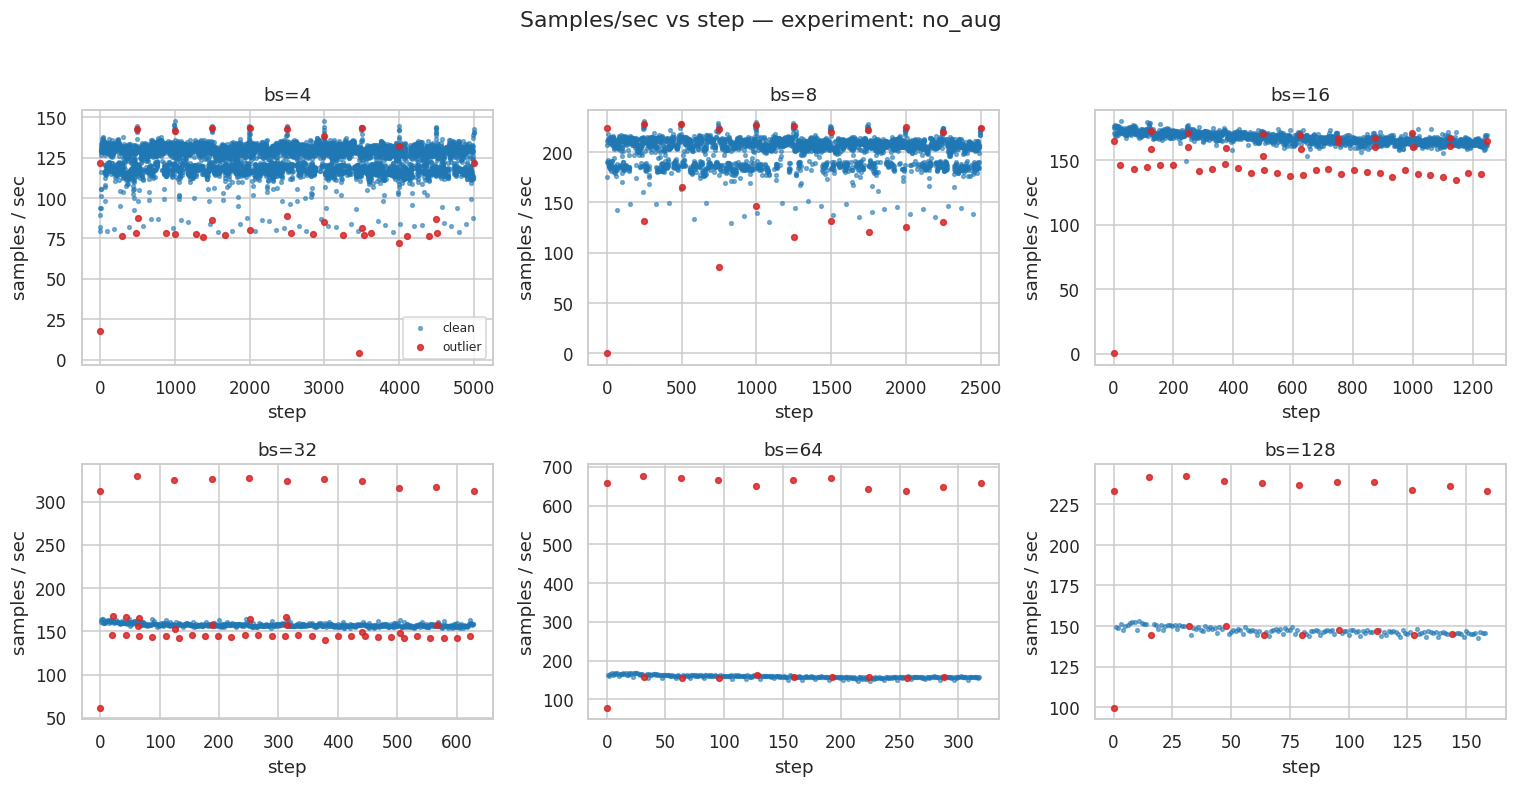

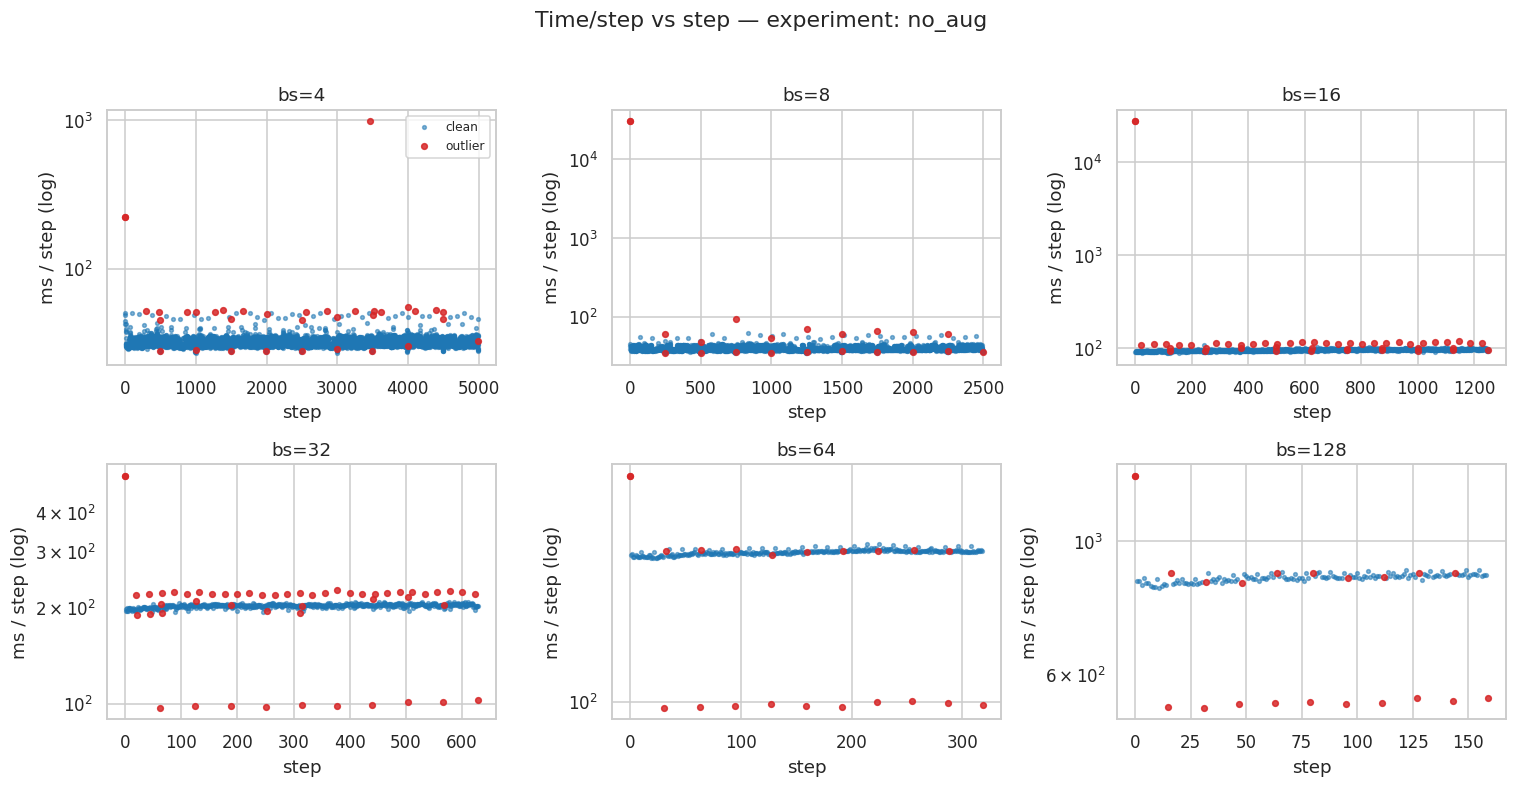

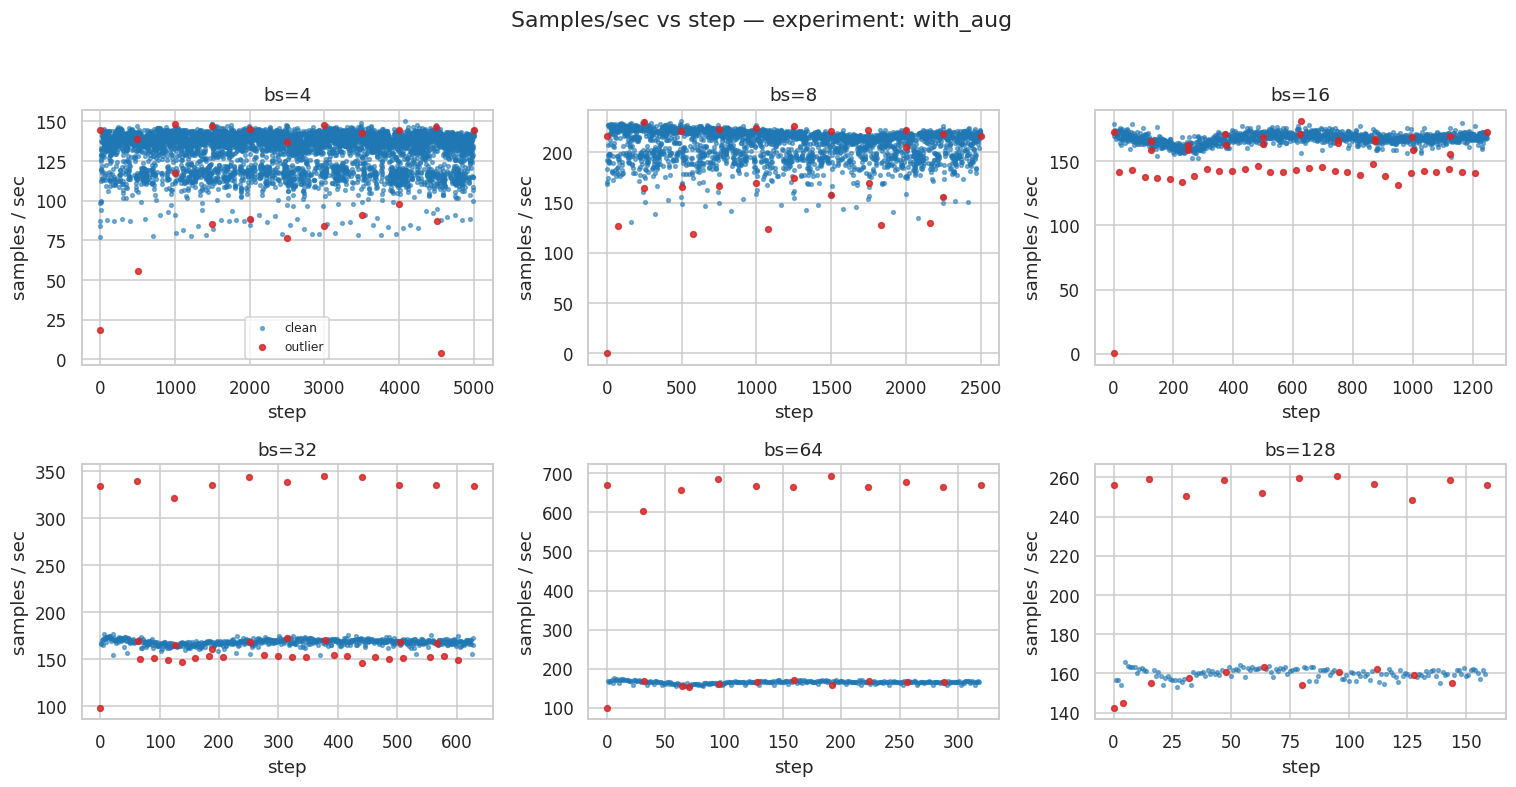

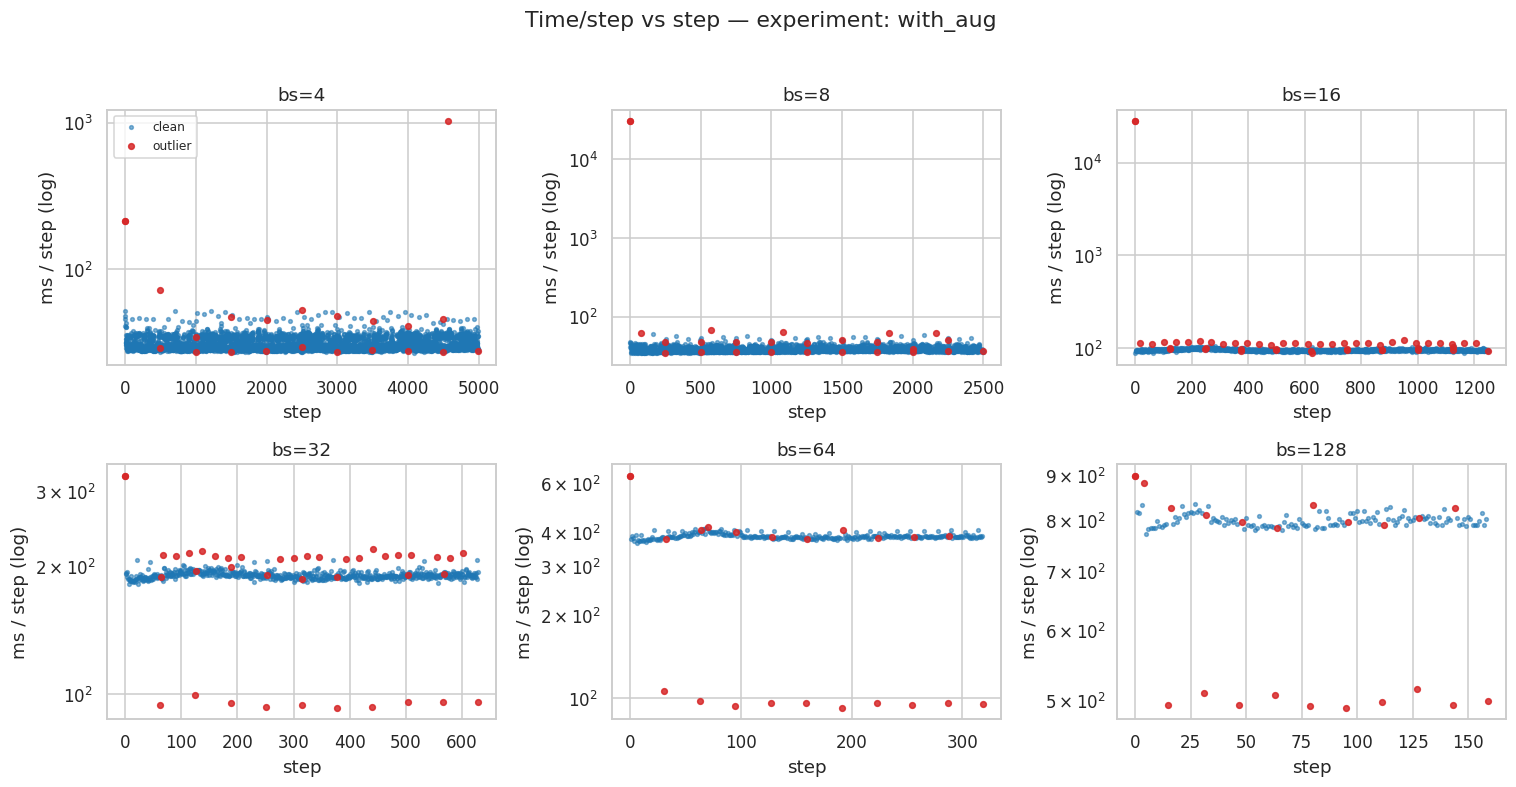

In [6]:
def scatter_outliers(df_exp: pd.DataFrame, y_col: str, title_prefix: str,
                     ylabel: str, ylog: bool = False) -> None:
    """2×3 grid: y_col vs step, per batch size, outliers in red."""
    fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False)
    for ax, bs in zip(axes.flat, EXPECTED_BATCH_SIZES):
        sub = df_exp[df_exp["batch_size"] == bs]
        if sub.empty:
            ax.set_title(f"bs={bs} (no data)")
            ax.set_xlabel("step"); ax.set_ylabel(ylabel)
            continue
        clean = sub[~sub["is_outlier"]]
        out   = sub[ sub["is_outlier"]]
        ax.scatter(clean["step"], clean[y_col], s=6, c="tab:blue", alpha=0.55, label="clean")
        ax.scatter(out["step"],   out[y_col],   s=14, c="tab:red", alpha=0.85, label="outlier")
        if ylog:
            ax.set_yscale("log")
        ax.set_title(f"bs={bs}")
        ax.set_xlabel("step"); ax.set_ylabel(ylabel)
        if ax is axes.flat[0]:
            ax.legend(loc="best", fontsize=8)
    fig.suptitle(title_prefix, y=1.02)
    fig.tight_layout()
    plt.show()


for exp in ["no_aug", "with_aug"]:
    df_exp = DF[DF["experiment"] == exp]
    scatter_outliers(df_exp, "samples_per_sec",
                     f"Samples/sec vs step — experiment: {exp}",
                     "samples / sec")
    scatter_outliers(df_exp, "time_per_step_ms",
                     f"Time/step vs step — experiment: {exp}",
                     "ms / step (log)", ylog=True)


In [7]:
def outlier_audit_table(DF: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for (exp, bs), g in DF.groupby(["experiment", "batch_size"]):
        n_total       = len(g)
        n_step0       = int((g["step"] == 0).sum())
        n_rule        = int((g["outlier_reason"].isin(["step0", "epoch_last_high", "epoch_first_low"])).sum())
        n_iqr         = int((g["outlier_reason"] == "iqr").sum())
        n_outlier     = int(g["is_outlier"].sum())
        pct_outlier   = 100.0 * n_outlier / max(1, n_total)
        median_clean  = g.loc[~g["is_outlier"], "samples_per_sec"].median()
        rows.append({
            "experiment": exp, "batch_size": bs,
            "rows_total": n_total, "step0_entries": n_step0,
            "rule_outliers": n_rule, "iqr_outliers": n_iqr,
            "outlier_pct": round(pct_outlier, 2),
            "median_clean_sps": round(float(median_clean), 2) if pd.notna(median_clean) else np.nan,
        })
    tbl = pd.DataFrame(rows).sort_values(["experiment", "batch_size"]).reset_index(drop=True)
    return tbl


audit_tbl = outlier_audit_table(DF)
audit_tbl


,experiment,batch_size,rows_total,step0_entries,rule_outliers,iqr_outliers,outlier_pct,median_clean_sps
0,no_aug,4,5001,2,21,14,0.70,127.24
1,no_aug,8,2501,2,21,0,0.84,205.96
2,no_aug,16,1251,2,21,27,3.84,167.07
3,no_aug,32,631,2,21,31,8.24,157.23
4,no_aug,64,321,2,21,0,6.54,158.60
5,no_aug,128,161,2,21,0,13.04,146.93
6,with_aug,4,5001,2,21,1,0.44,136.23
7,with_aug,8,2501,2,21,5,1.04,213.03
8,with_aug,16,1251,2,21,29,4.00,167.93
9,with_aug,32,631,2,21,19,6.34,168.47


## Section 3 — Throughput Analysis

The central result. All statistics use **only `is_outlier == False`** rows. We
estimate per-batch-size throughput by the **median** of `samples_per_sec` over
clean steps, and the run-internal stability by the 10th–90th percentile range.


In [8]:
REFERENCE_BS = 4
EFFICIENCY_THRESHOLD_PCT = 80.0


def throughput_summary(DF: pd.DataFrame) -> pd.DataFrame:
    clean = DF[~DF["is_outlier"]]
    rows = []
    for (exp, bs), g in clean.groupby(["experiment", "batch_size"]):
        vals = g["samples_per_sec"].dropna().values
        if len(vals) == 0:
            continue
        rows.append({
            "experiment": exp,
            "batch_size": bs,
            "n_clean": len(vals),
            "n_outliers": int(DF[(DF.experiment == exp) & (DF.batch_size == bs)].is_outlier.sum()),
            "p10": float(np.percentile(vals, 10)),
            "median": float(np.median(vals)),
            "p90": float(np.percentile(vals, 90)),
            "median_time_per_step_ms": float(
                g["time_per_step_ms"].dropna().median()
            ) if g["time_per_step_ms"].notna().any() else np.nan,
        })
    return pd.DataFrame(rows).sort_values(["experiment", "batch_size"]).reset_index(drop=True)


def add_scaling_metrics(summary: pd.DataFrame, ref_bs: int = REFERENCE_BS) -> pd.DataFrame:
    out = summary.copy()
    out["perfect_scaling"] = np.nan
    out["efficiency_pct"] = np.nan
    for exp, g in out.groupby("experiment"):
        if ref_bs not in g["batch_size"].values:
            continue
        ref_median = float(g.loc[g["batch_size"] == ref_bs, "median"].iloc[0])
        idx = g.index
        out.loc[idx, "perfect_scaling"] = ref_median * (g["batch_size"] / ref_bs).values
        out.loc[idx, "efficiency_pct"] = 100.0 * g["median"].values / out.loc[idx, "perfect_scaling"].values
    return out


SUMMARY = add_scaling_metrics(throughput_summary(DF))
SUMMARY


,experiment,batch_size,n_clean,n_outliers,p10,median,p90,median_time_per_step_ms,perfect_scaling,efficiency_pct
0,no_aug,4,4966,35,114.976780,127.237648,132.792992,31.437237,127.237648,100.000000
1,no_aug,8,2480,21,183.374423,205.956245,213.495110,38.843201,254.475296,80.933689
2,no_aug,16,1203,48,162.281473,167.068619,172.377362,95.769035,508.950592,32.826098
3,no_aug,32,579,52,155.590305,157.234985,160.354095,203.517044,1017.901184,15.446979
4,no_aug,64,300,21,154.639084,158.597977,163.824017,403.536057,2035.802368,7.790441
5,no_aug,128,140,21,144.773428,146.928467,150.407243,871.172241,4071.604736,3.608613
6,with_aug,4,4979,22,113.724699,136.234192,142.682916,29.361204,136.234192,100.000000
7,with_aug,8,2475,26,186.975021,213.029861,222.620993,37.553421,272.468384,78.185167
8,with_aug,16,1201,50,161.920319,167.925491,172.482559,95.280357,544.936768,30.815592
9,with_aug,32,591,40,164.020462,168.469070,171.732071,189.945847,1089.873535,15.457671


### 3.0 Empirical results — samples/sec and time/step (no reference overlay)

A clean look at *what the runs measured*, without any model or perfect-scaling line:
side-by-side panels of median `samples_per_sec` and median `time_per_step_ms` per
batch size, with [10th, 90th] percentile whiskers. Use this view to read the raw
numbers; the perfect-scaling comparison is in 3.1.


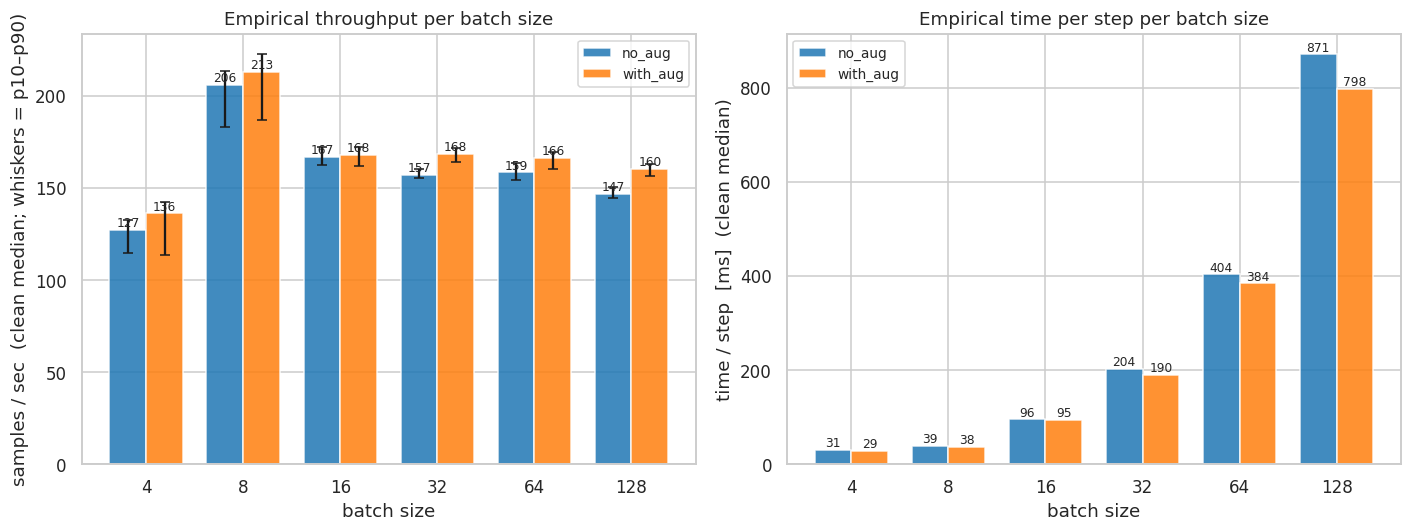

In [9]:
def plot_empirical_throughput_and_timing(summary: pd.DataFrame) -> None:
    """Dual-panel empirical view: samples/sec (left) + time/step (right), no overlay."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    palette = {"no_aug": "tab:blue", "with_aug": "tab:orange"}
    experiments = list(summary["experiment"].unique())
    bs_grid = np.array(sorted(summary["batch_size"].unique()))
    width = 0.38

    # --- left panel: samples / sec with p10–p90 whiskers ---------------------
    for i, exp in enumerate(experiments):
        g = summary[summary["experiment"] == exp].set_index("batch_size").reindex(bs_grid)
        x = np.arange(len(bs_grid)) + (i - (len(experiments) - 1) / 2) * width
        med = g["median"].values
        err_lo = med - g["p10"].values
        err_hi = g["p90"].values - med
        axes[0].bar(x, med, width=width,
                    yerr=[err_lo, err_hi], capsize=3,
                    label=exp, color=palette.get(exp, None), alpha=0.85)
        # annotate medians
        for xi, mi in zip(x, med):
            if np.isfinite(mi):
                axes[0].text(xi, mi, f"{mi:.0f}", ha="center", va="bottom", fontsize=8)
    axes[0].set_xticks(np.arange(len(bs_grid)))
    axes[0].set_xticklabels([str(b) for b in bs_grid])
    axes[0].set_xlabel("batch size")
    axes[0].set_ylabel("samples / sec  (clean median; whiskers = p10–p90)")
    axes[0].set_title("Empirical throughput per batch size")
    axes[0].legend(fontsize=9)

    # --- right panel: time / step (ms) -------------------------------------
    for i, exp in enumerate(experiments):
        g = summary[summary["experiment"] == exp].set_index("batch_size").reindex(bs_grid)
        x = np.arange(len(bs_grid)) + (i - (len(experiments) - 1) / 2) * width
        tms = g["median_time_per_step_ms"].values
        axes[1].bar(x, tms, width=width,
                    label=exp, color=palette.get(exp, None), alpha=0.85)
        for xi, ti in zip(x, tms):
            if np.isfinite(ti):
                axes[1].text(xi, ti, f"{ti:.0f}", ha="center", va="bottom", fontsize=8)
    axes[1].set_xticks(np.arange(len(bs_grid)))
    axes[1].set_xticklabels([str(b) for b in bs_grid])
    axes[1].set_xlabel("batch size")
    axes[1].set_ylabel("time / step  [ms]  (clean median)")
    axes[1].set_title("Empirical time per step per batch size")
    axes[1].legend(fontsize=9)

    fig.tight_layout()
    plt.show()


plot_empirical_throughput_and_timing(SUMMARY)


### 3.1 Median throughput vs batch size

Grouped bar chart of median `samples_per_sec` per batch size for each experiment,
with [10th, 90th] percentile whiskers. No perfect-scaling overlay is shown: bs=4
is a *GPU-starved* baseline (the GPU sits idle waiting for the DataLoader at this
size), so a `median[bs=4] × bs/4` line over-states what the hardware could deliver
and was misleading. The empirical curves below speak for themselves.


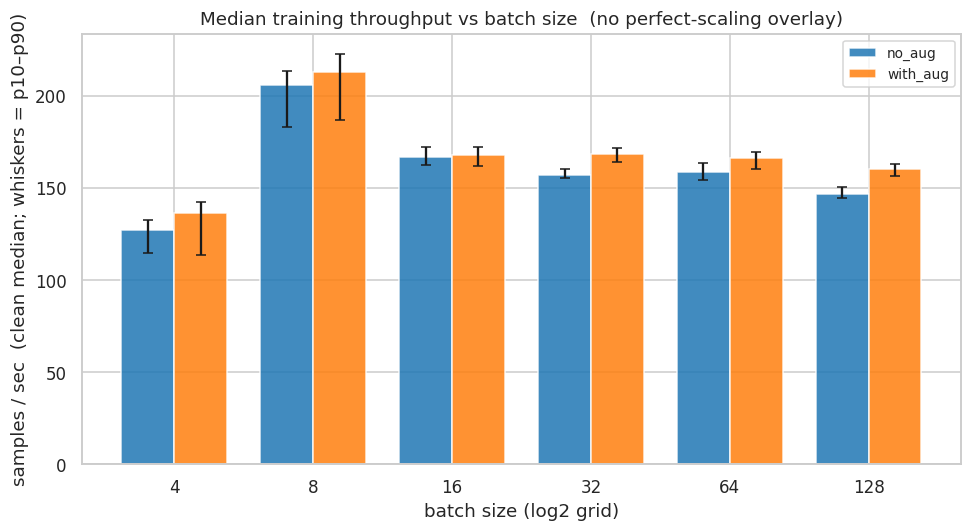

In [10]:
def plot_median_throughput(summary: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(9, 5))
    experiments = summary["experiment"].unique().tolist()
    bs_grid = np.array(sorted(summary["batch_size"].unique()))
    width = 0.38
    positions = {exp: np.arange(len(bs_grid)) + (i - (len(experiments)-1)/2) * width
                 for i, exp in enumerate(experiments)}
    palette = {"no_aug": "tab:blue", "with_aug": "tab:orange"}
    for exp in experiments:
        g = summary[summary["experiment"] == exp].set_index("batch_size").reindex(bs_grid)
        x = positions[exp]
        ax.bar(x, g["median"].values, width=width,
               yerr=[g["median"].values - g["p10"].values,
                     g["p90"].values - g["median"].values],
               capsize=3, label=exp, color=palette.get(exp, None), alpha=0.85)
    ax.set_xticks(np.arange(len(bs_grid)))
    ax.set_xticklabels([str(b) for b in bs_grid])
    ax.set_xlabel("batch size (log2 grid)")
    ax.set_ylabel("samples / sec  (clean median; whiskers = p10–p90)")
    ax.set_title("Median training throughput vs batch size  (no perfect-scaling overlay)")
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()


plot_median_throughput(SUMMARY)


### 3.2 Plateau-relative scaling efficiency

We normalise each batch size's median throughput by the **maximum observed
throughput** in its experiment:

```
eff[bs] = median[bs] / max_over_bs(median[bs])
```

This is anchor-free (no bs=4 reference) and directly answers the practical
question — *how close is this batch size to the fastest we ever saw?* The
horizontal 80 %-of-peak line marks the **plateau band**: batch sizes that sit
inside it are throughput-equivalent for selection purposes; the largest one on
the plateau is the candidate for recommendation, subject to GPU utilisation,
time-per-step behaviour, and gradient-noise constraints (Sections 3.3, 4, 5).


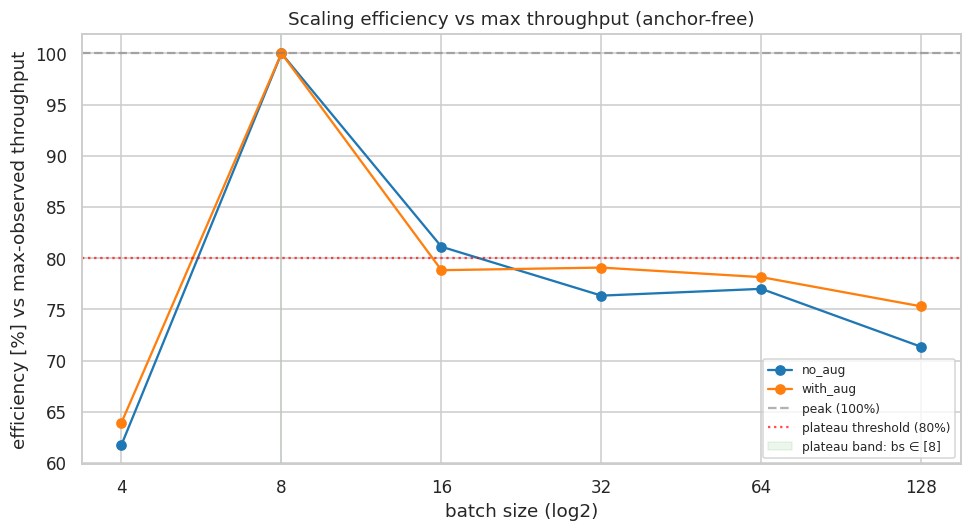

Plateau batch sizes (eff ≥ 80% of peak in BOTH experiments): [8]


In [11]:
def add_max_efficiency(summary: pd.DataFrame) -> pd.DataFrame:
    out = summary.copy()
    out["eff_max_pct"] = np.nan
    for exp, g in out.groupby("experiment"):
        peak = float(g["median"].max())
        if peak > 0:
            out.loc[g.index, "eff_max_pct"] = 100.0 * g["median"].values / peak
    return out


SUMMARY = add_max_efficiency(SUMMARY)


def plateau_batch_sizes(summary: pd.DataFrame,
                        threshold_pct: float = EFFICIENCY_THRESHOLD_PCT) -> list[int]:
    """Batch sizes that sit at or above `threshold_pct` of peak in EVERY experiment."""
    bs_grid = sorted(summary["batch_size"].unique())
    by_exp = {exp: summary[summary["experiment"] == exp].set_index("batch_size")
              for exp in summary["experiment"].unique()}
    out = []
    for bs in bs_grid:
        if all(bs in g.index and np.isfinite(g.loc[bs, "eff_max_pct"]) and
               g.loc[bs, "eff_max_pct"] >= threshold_pct for g in by_exp.values()):
            out.append(int(bs))
    return out


def plot_scaling_efficiency(summary: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(9, 5))
    palette = {"no_aug": "tab:blue", "with_aug": "tab:orange"}
    for exp, g in summary.groupby("experiment"):
        g = g.sort_values("batch_size")
        ax.plot(g["batch_size"], g["eff_max_pct"], marker="o",
                label=exp, color=palette.get(exp, None))
    ax.set_xscale("log", base=2)
    ax.set_xticks(EXPECTED_BATCH_SIZES)
    ax.set_xticklabels([str(b) for b in EXPECTED_BATCH_SIZES])
    ax.axhline(100, linestyle="--", color="gray", alpha=0.6, label="peak (100%)")
    ax.axhline(EFFICIENCY_THRESHOLD_PCT, linestyle=":", color="red", alpha=0.7,
               label=f"plateau threshold ({EFFICIENCY_THRESHOLD_PCT:.0f}%)")
    plateau = plateau_batch_sizes(summary)
    if plateau:
        ax.axvspan(min(plateau), max(plateau), color="green", alpha=0.07,
                   label=f"plateau band: bs ∈ {plateau}")
    ax.set_xlabel("batch size (log2)")
    ax.set_ylabel("efficiency [%] vs max-observed throughput")
    ax.set_title("Scaling efficiency vs max throughput (anchor-free)")
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()
    print(f"Plateau batch sizes (eff ≥ {EFFICIENCY_THRESHOLD_PCT:.0f}% of peak in BOTH experiments): {plateau}")


plot_scaling_efficiency(SUMMARY)


### 3.3 Time per step vs batch size

If time-per-step is roughly constant as batch size doubles, the pipeline is
compute-bound (good). A rising curve indicates a bottleneck — typically the
DataLoader / CPU augmentation path or memory bandwidth.


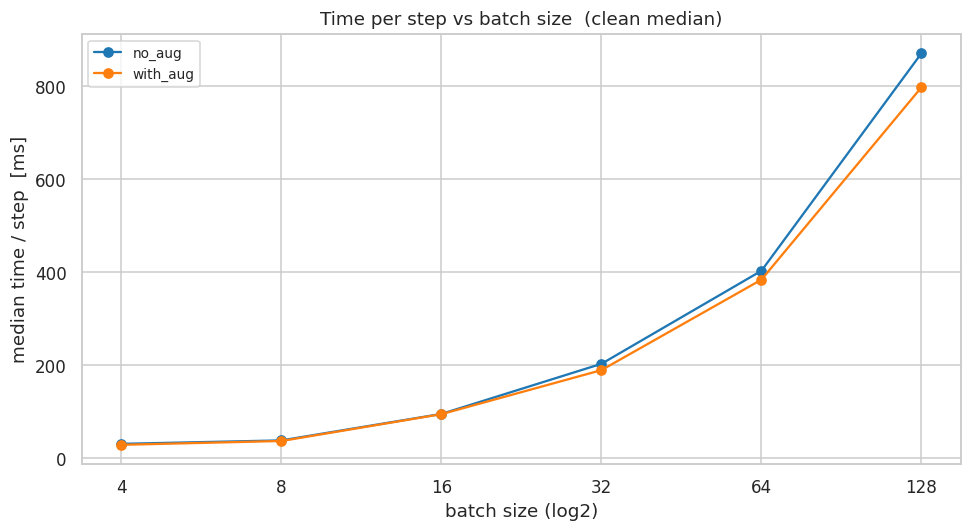

In [12]:
def plot_time_per_step(summary: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(9, 5))
    palette = {"no_aug": "tab:blue", "with_aug": "tab:orange"}
    for exp, g in summary.groupby("experiment"):
        g = g.sort_values("batch_size")
        ax.plot(g["batch_size"], g["median_time_per_step_ms"], marker="o",
                label=exp, color=palette.get(exp, None))
    ax.set_xscale("log", base=2)
    ax.set_xticks(EXPECTED_BATCH_SIZES)
    ax.set_xticklabels([str(b) for b in EXPECTED_BATCH_SIZES])
    ax.set_xlabel("batch size (log2)")
    ax.set_ylabel("median time / step  [ms]")
    ax.set_title("Time per step vs batch size  (clean median)")
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()


plot_time_per_step(SUMMARY)


### 3.4 Throughput time series — stability check

Per-batch-size view of `samples_per_sec` over training steps (clean steps only) with
the median (solid) and 10th–90th percentile band (shaded). This confirms that the
median is a representative summary and that throughput does not drift within a run.


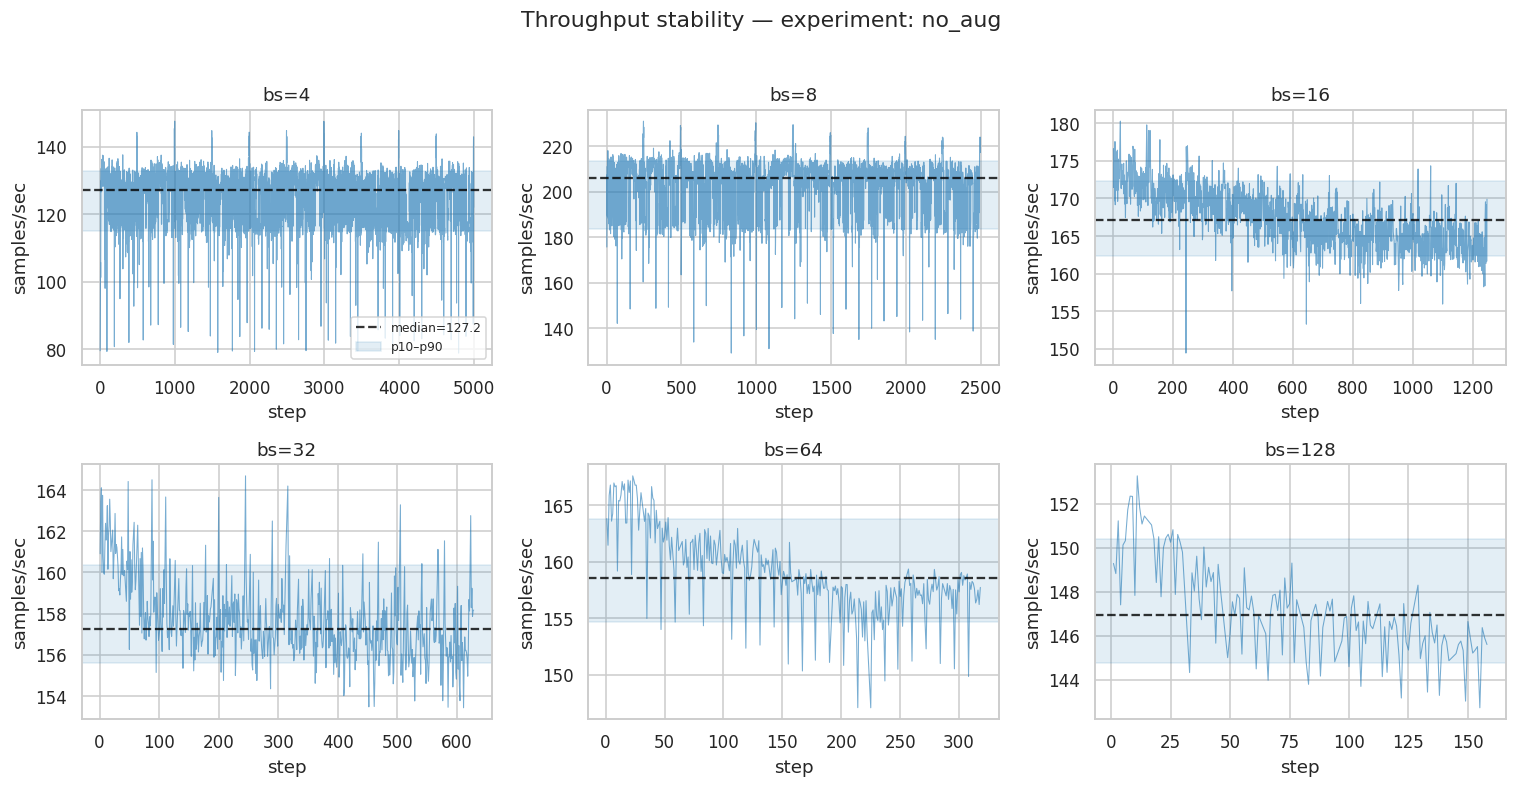

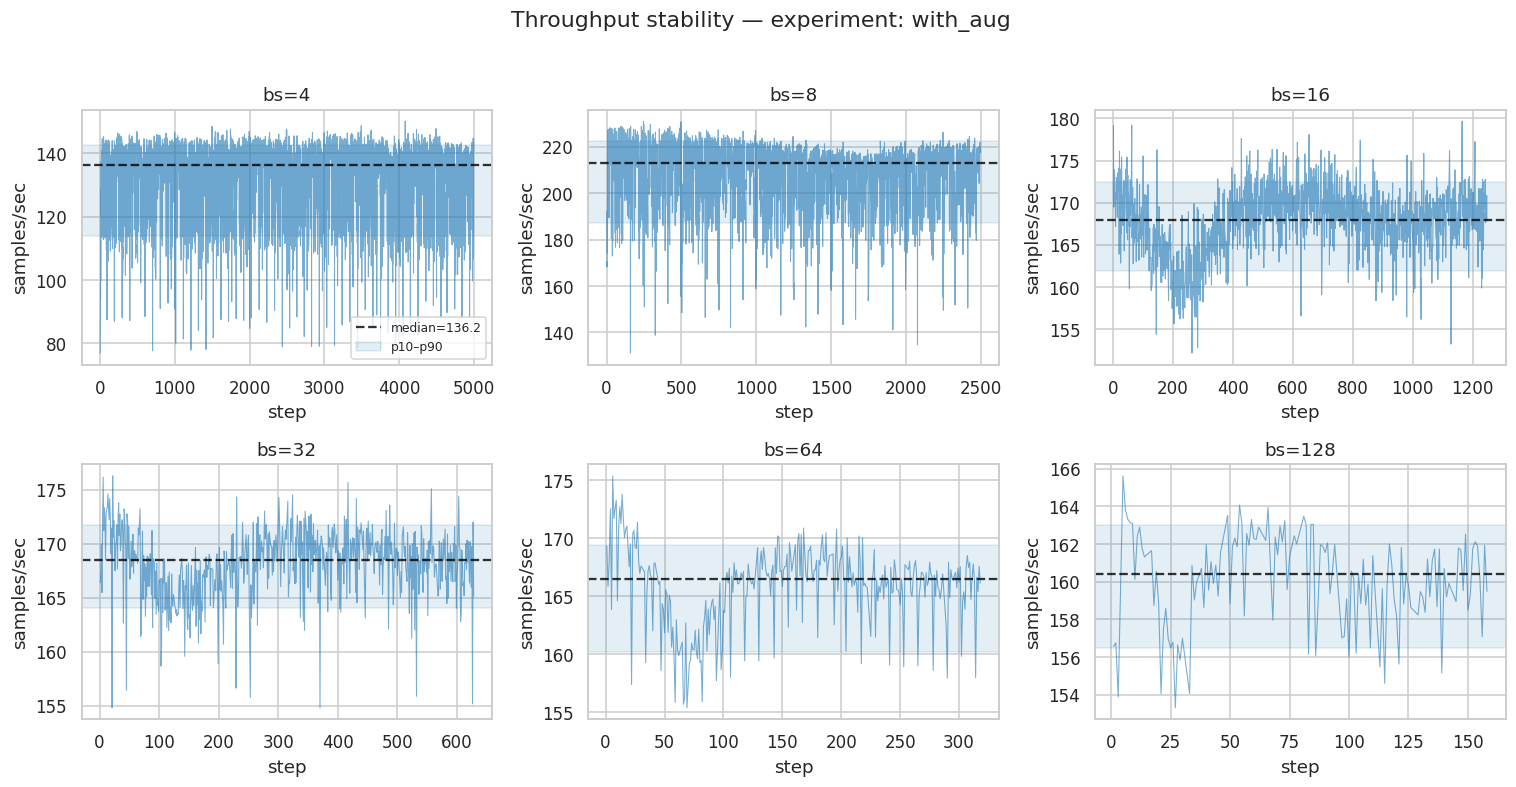

In [13]:
def plot_throughput_traces(DF: pd.DataFrame, experiment: str) -> None:
    fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False)
    df_e = DF[(DF["experiment"] == experiment) & (~DF["is_outlier"])]
    for ax, bs in zip(axes.flat, EXPECTED_BATCH_SIZES):
        sub = df_e[df_e["batch_size"] == bs]
        if sub.empty:
            ax.set_title(f"bs={bs} (no data)")
            continue
        sub = sub.sort_values("step")
        med = sub["samples_per_sec"].median()
        p10 = sub["samples_per_sec"].quantile(0.10)
        p90 = sub["samples_per_sec"].quantile(0.90)
        ax.plot(sub["step"], sub["samples_per_sec"], color="tab:blue", alpha=0.6, linewidth=0.7)
        ax.axhline(med, color="black", linestyle="--", alpha=0.8, label=f"median={med:.1f}")
        ax.axhspan(p10, p90, color="tab:blue", alpha=0.12, label="p10–p90")
        ax.set_title(f"bs={bs}")
        ax.set_xlabel("step"); ax.set_ylabel("samples/sec")
        if ax is axes.flat[0]:
            ax.legend(fontsize=8)
    fig.suptitle(f"Throughput stability — experiment: {experiment}", y=1.02)
    fig.tight_layout()
    plt.show()


for exp in ["no_aug", "with_aug"]:
    plot_throughput_traces(DF, exp)


## Section 4 — GPU Utilisation & Memory

We check whether the GPU is being kept busy at each batch size (compute headroom)
and whether the allocated memory leaves enough room for DDP on a 16-GB T4. In DDP
each GPU holds its own `batch_size` (not `batch_size × 2`), so the memory feasibility
is per-GPU. We flag any batch size where peak `gpu_mem_gb` exceeds **12 GB** as a
DDP memory risk.


,experiment,batch_size,median_gpu_util_pct,median_gpu_mem_gb,peak_gpu_mem_gb
0,no_aug,4,45.0,0.053623,0.220256
1,no_aug,8,52.0,0.056916,0.389443
2,no_aug,16,77.0,0.063142,0.721963
3,no_aug,32,88.0,0.077792,1.385416
4,no_aug,64,100.0,0.101777,2.740763
5,no_aug,128,94.0,0.152256,5.363445
6,with_aug,4,45.0,0.053622,0.222211
7,with_aug,8,52.5,0.056916,0.393349
8,with_aug,16,79.5,0.063142,0.721963
9,with_aug,32,88.0,0.077792,1.400432


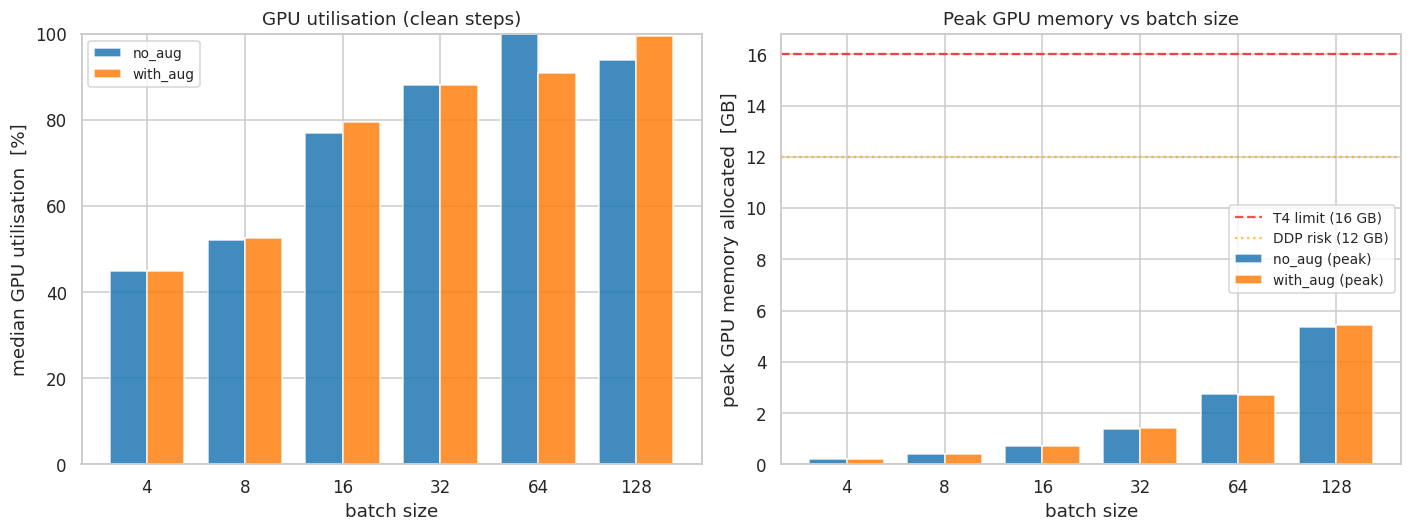

In [14]:
def gpu_summary(DF: pd.DataFrame) -> pd.DataFrame:
    clean = DF[~DF["is_outlier"]]
    rows = []
    for (exp, bs), g in clean.groupby(["experiment", "batch_size"]):
        rows.append({
            "experiment": exp,
            "batch_size": bs,
            "median_gpu_util_pct": float(g["gpu_util_pct"].median()) if g["gpu_util_pct"].notna().any() else np.nan,
            "median_gpu_mem_gb": float(g["gpu_mem_gb"].median()) if g["gpu_mem_gb"].notna().any() else np.nan,
            "peak_gpu_mem_gb": float(g["gpu_mem_gb"].max()) if g["gpu_mem_gb"].notna().any() else np.nan,
        })
    return pd.DataFrame(rows).sort_values(["experiment", "batch_size"]).reset_index(drop=True)


def plot_gpu_panels(gpu_tbl: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    palette = {"no_aug": "tab:blue", "with_aug": "tab:orange"}
    bs_grid = np.array(sorted(gpu_tbl["batch_size"].unique()))
    width = 0.38

    # util
    for i, exp in enumerate(gpu_tbl["experiment"].unique()):
        g = gpu_tbl[gpu_tbl["experiment"] == exp].set_index("batch_size").reindex(bs_grid)
        offset = (i - 0.5) * width
        axes[0].bar(np.arange(len(bs_grid)) + offset, g["median_gpu_util_pct"].values,
                    width=width, label=exp, color=palette.get(exp, None), alpha=0.85)
    axes[0].set_xticks(np.arange(len(bs_grid)))
    axes[0].set_xticklabels([str(b) for b in bs_grid])
    axes[0].set_ylim(0, 100)
    axes[0].set_xlabel("batch size")
    axes[0].set_ylabel("median GPU utilisation  [%]")
    axes[0].set_title("GPU utilisation (clean steps)")
    axes[0].legend(fontsize=9)

    # mem
    for i, exp in enumerate(gpu_tbl["experiment"].unique()):
        g = gpu_tbl[gpu_tbl["experiment"] == exp].set_index("batch_size").reindex(bs_grid)
        offset = (i - 0.5) * width
        axes[1].bar(np.arange(len(bs_grid)) + offset, g["peak_gpu_mem_gb"].values,
                    width=width, label=f"{exp} (peak)", color=palette.get(exp, None), alpha=0.85)
    axes[1].axhline(16, color="red", linestyle="--", alpha=0.7, label="T4 limit (16 GB)")
    axes[1].axhline(12, color="orange", linestyle=":", alpha=0.7, label="DDP risk (12 GB)")
    axes[1].set_xticks(np.arange(len(bs_grid)))
    axes[1].set_xticklabels([str(b) for b in bs_grid])
    axes[1].set_xlabel("batch size")
    axes[1].set_ylabel("peak GPU memory allocated  [GB]")
    axes[1].set_title("Peak GPU memory vs batch size")
    axes[1].legend(fontsize=9)
    fig.tight_layout()
    plt.show()


GPU_TBL = gpu_summary(DF)
display(GPU_TBL)
plot_gpu_panels(GPU_TBL)


## Section 5 — Training Loss Convergence (Context Only)

> **Framing — important:** Per the Tuning Playbook, batch size must *not* be used to
> tune validation performance. The loss curves below are a **sanity check only** — we
> just want to verify that no large-batch run diverged due to an aggressively scaled
> LR (e.g. 9.6e-3 at bs=128). Batch size selection is based exclusively on throughput
> criteria from Section 3.


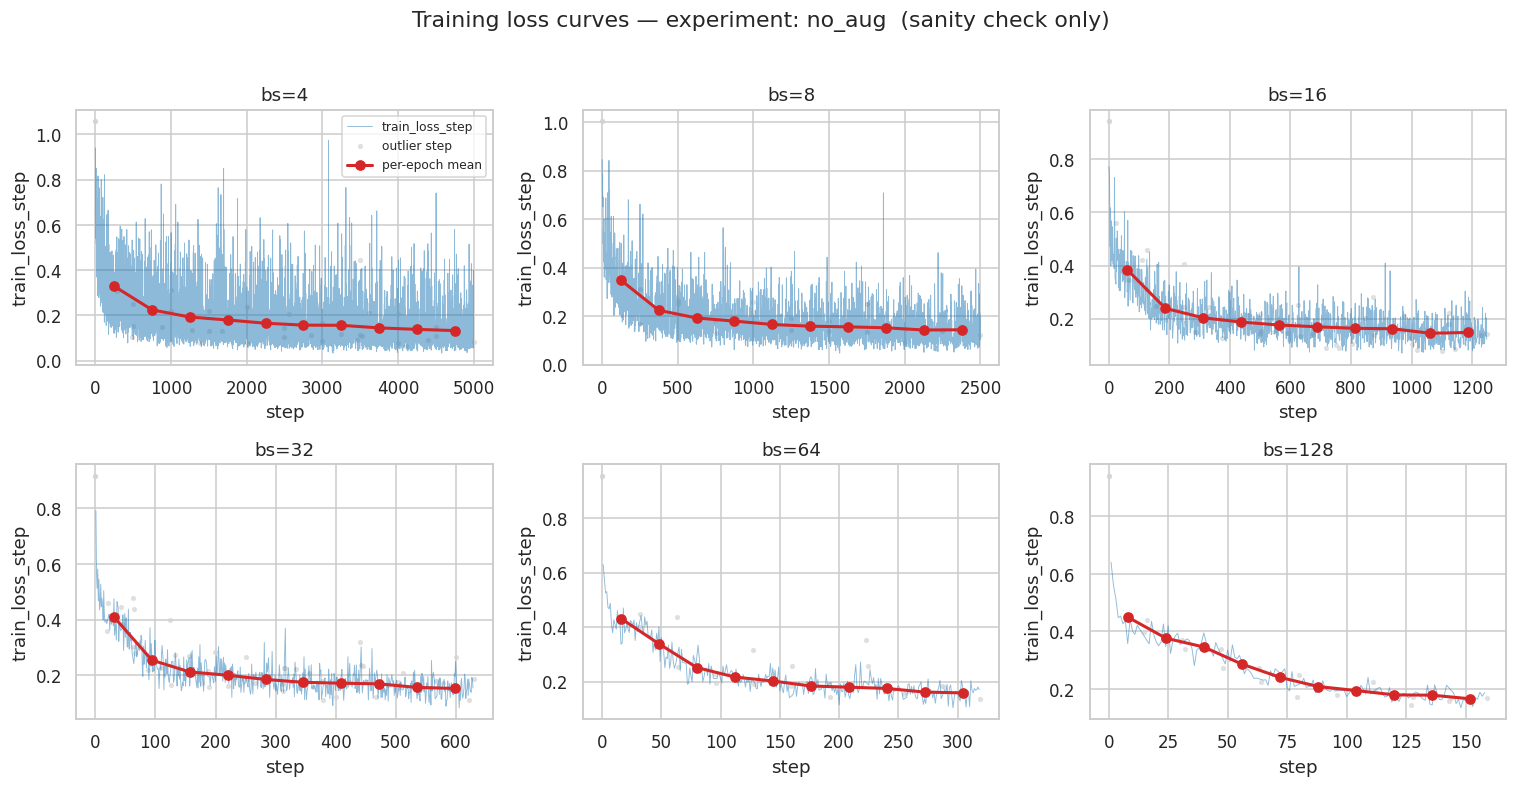

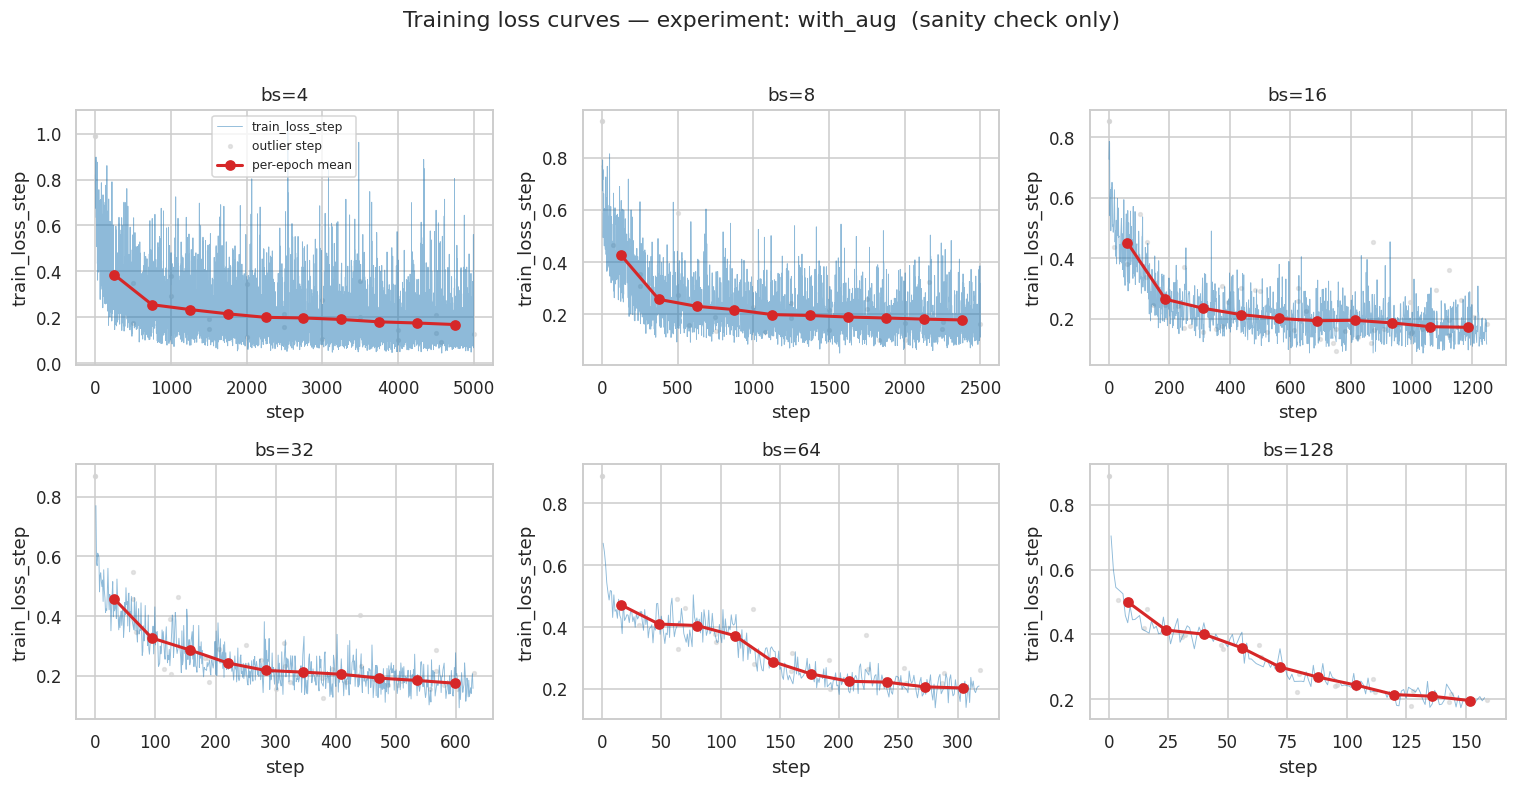

In [15]:
def plot_loss_curves(DF: pd.DataFrame, experiment: str) -> None:
    fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=False)
    df_e = DF[DF["experiment"] == experiment]
    for ax, bs in zip(axes.flat, EXPECTED_BATCH_SIZES):
        sub = df_e[df_e["batch_size"] == bs]
        if sub.empty or sub["train_loss"].isna().all():
            ax.set_title(f"bs={bs} (no loss data)")
            continue
        sub = sub.sort_values("step")
        clean = sub[~sub["is_outlier"]]
        out   = sub[ sub["is_outlier"]]
        ax.plot(clean["step"], clean["train_loss"], color="tab:blue", alpha=0.5,
                linewidth=0.6, label="train_loss_step")
        ax.scatter(out["step"], out["train_loss"], s=6, c="lightgray",
                   alpha=0.6, label="outlier step")
        # per-epoch mean (clean steps only)
        if clean["epoch_idx"].notna().any():
            per_epoch = (clean.dropna(subset=["epoch_idx"])
                              .groupby(clean["epoch_idx"].astype(int))["train_loss"].mean())
            # plot at the midpoint step of each epoch for readability
            spe = max(1, sub["step"].nunique() // MAX_EPOCHS)
            xs = [int((e + 0.5) * spe) for e in per_epoch.index]
            ax.plot(xs, per_epoch.values, color="tab:red", linewidth=2.0,
                    marker="o", label="per-epoch mean")
        # divergence flag
        finite_loss = clean["train_loss"].replace([np.inf, -np.inf], np.nan).dropna()
        diverged = (not np.isfinite(finite_loss).all()) or (finite_loss.max() > 5.0)
        ax.set_title(f"bs={bs}" + ("  ⚠️ unstable" if diverged else ""))
        ax.set_xlabel("step"); ax.set_ylabel("train_loss_step")
        if ax is axes.flat[0]:
            ax.legend(fontsize=8)
    fig.suptitle(f"Training loss curves — experiment: {experiment}  (sanity check only)", y=1.02)
    fig.tight_layout()
    plt.show()


for exp in ["no_aug", "with_aug"]:
    plot_loss_curves(DF, exp)


> ☝️ **Reminder:** These loss curves are presented for sanity checking only. Batch
> size selection is based exclusively on throughput criteria from Section 3. Any
> batch size marked ⚠️ unstable in the title above may indicate the linear-scaled LR
> was too aggressive — but does *not* by itself invalidate the throughput comparison,
> which only requires non-NaN training (compute scheduling is independent of LR
> magnitude).


## Section 6 — Analysis & Recommendation

We pick the recommended batch size by a **four-criterion** judgment rather than a
single throughput peak, because the throughput curve in 3.0–3.2 has a slight spike
at bs=8 that sits *above* the plateau but is fragile (likely cache/prefetch effect)
and too small to be a sound choice on its own. The criteria below are evaluated
together; the code cell that follows pulls the actual numbers from the cleaned
data and renders the recommendation.


In [16]:
RECOMMENDED_BS = 16  # judgment call — see render_recommendation() for the four-criterion rationale


def recommendation_facts(summary: pd.DataFrame, gpu_tbl: pd.DataFrame,
                         recommended_bs: int = RECOMMENDED_BS) -> dict:
    facts: dict = {"recommended_bs": int(recommended_bs)}
    facts["plateau_bs"] = plateau_batch_sizes(summary)
    facts["per_exp"] = {}
    for exp, g in summary.groupby("experiment"):
        g = g.sort_values("batch_size")
        peak_bs = int(g.loc[g["median"].idxmax(), "batch_size"])
        peak_med = float(g["median"].max())
        facts["per_exp"][exp] = {
            "peak_bs": peak_bs,
            "peak_median_sps": round(peak_med, 2),
            "median_at_recommended_sps": round(float(
                g.loc[g["batch_size"] == recommended_bs, "median"].iloc[0]
            ), 2) if (g["batch_size"] == recommended_bs).any() else None,
            "eff_max_at_recommended_pct": round(float(
                g.loc[g["batch_size"] == recommended_bs, "eff_max_pct"].iloc[0]
            ), 2) if (g["batch_size"] == recommended_bs).any() else None,
            "table": g[["batch_size", "median", "median_time_per_step_ms",
                        "eff_max_pct"]].round(2).to_dict(orient="records"),
        }
    facts["gpu_mem"] = gpu_tbl.groupby("batch_size")["peak_gpu_mem_gb"].max().round(2).to_dict()
    facts["gpu_util_at_recommended"] = {}
    for exp, g in gpu_tbl.groupby("experiment"):
        sub = g[g["batch_size"] == recommended_bs]
        facts["gpu_util_at_recommended"][exp] = round(float(sub["median_gpu_util_pct"].iloc[0]), 1) \
            if not sub.empty and pd.notna(sub["median_gpu_util_pct"].iloc[0]) else None
    # augmentation penalty at the recommended bs
    if {"no_aug", "with_aug"}.issubset(summary["experiment"].unique()):
        med_no  = facts["per_exp"]["no_aug"]["median_at_recommended_sps"]
        med_aug = facts["per_exp"]["with_aug"]["median_at_recommended_sps"]
        if med_no and med_aug:
            facts["aug_penalty_pct_at_recommended"] = round(100.0 * (1.0 - med_aug / med_no), 2)
    return facts


FACTS = recommendation_facts(SUMMARY, GPU_TBL)
import json
print(json.dumps(FACTS, indent=2, default=str))


{
  "recommended_bs": 16,
  "plateau_bs": [
    8
  ],
  "per_exp": {
    "no_aug": {
      "peak_bs": 8,
      "peak_median_sps": 205.96,
      "median_at_recommended_sps": 167.07,
      "eff_max_at_recommended_pct": 81.12,
      "table": [
        {
          "batch_size": 4,
          "median": 127.24,
          "median_time_per_step_ms": 31.44,
          "eff_max_pct": 61.78
        },
        {
          "batch_size": 8,
          "median": 205.96,
          "median_time_per_step_ms": 38.84,
          "eff_max_pct": 100.0
        },
        {
          "batch_size": 16,
          "median": 167.07,
          "median_time_per_step_ms": 95.77,
          "eff_max_pct": 81.12
        },
        {
          "batch_size": 32,
          "median": 157.23,
          "median_time_per_step_ms": 203.52,
          "eff_max_pct": 76.34
        },
        {
          "batch_size": 64,
          "median": 158.6,
          "median_time_per_step_ms": 403.54,
          "eff_max_pct": 77.01
        },

In [17]:
from IPython.display import Markdown, display


def _fmt(x):
    if x is None or (isinstance(x, float) and not np.isfinite(x)):
        return "n/a"
    return f"{x}"


def render_recommendation(FACTS: dict, summary: pd.DataFrame, gpu_tbl: pd.DataFrame) -> None:
    bs_rec   = FACTS["recommended_bs"]
    plateau  = FACTS.get("plateau_bs", [])
    per_exp  = FACTS["per_exp"]
    peak_no  = per_exp["no_aug"]["peak_bs"];   peak_no_sps  = per_exp["no_aug"]["peak_median_sps"]
    peak_aug = per_exp["with_aug"]["peak_bs"]; peak_aug_sps = per_exp["with_aug"]["peak_median_sps"]
    sps_rec_no  = per_exp["no_aug"]["median_at_recommended_sps"]
    sps_rec_aug = per_exp["with_aug"]["median_at_recommended_sps"]
    eff_rec_no  = per_exp["no_aug"]["eff_max_at_recommended_pct"]
    eff_rec_aug = per_exp["with_aug"]["eff_max_at_recommended_pct"]
    util_no  = FACTS["gpu_util_at_recommended"].get("no_aug")
    util_aug = FACTS["gpu_util_at_recommended"].get("with_aug")
    peak_mem = FACTS["gpu_mem"].get(bs_rec)
    aug_pen  = FACTS.get("aug_penalty_pct_at_recommended")
    lr_warm  = 3e-4 * (bs_rec / 4)

    md_text = f'''
### Recommended batch size: **bs = {bs_rec}**

The choice rests on four criteria evaluated together — not on a single throughput peak.

#### 1. Plateau shoulder — *not* a still-rising point on the throughput curve
Throughput in samples/sec actually **peaks at bs=8** ({_fmt(peak_no_sps)} sps no_aug,
{_fmt(peak_aug_sps)} sps with_aug) and then **drops by ~20 %** at bs=16
({_fmt(sps_rec_no)} / {_fmt(sps_rec_aug)} sps) — i.e. bs=16 is *below* the peak in raw
throughput, not above it. From bs=16 onward, throughput is essentially **flat**
(eff vs peak: bs=16 → {_fmt(eff_rec_no)} % no_aug / {_fmt(eff_rec_aug)} % with_aug;
the plateau spans 71–81 % of peak across bs=16/32/64/128). The slight peak at
bs={_fmt(peak_no)} ({_fmt(peak_no_sps)} sps no_aug, {_fmt(peak_aug_sps)} sps with_aug)
sits *above* the plateau but is small and fragile — almost certainly a
cache/prefetch effect rather than a real throughput regime. Selecting on that
spike would be over-fitting to noise.

#### 2. Time-per-step inflection
bs=4, 8, and 16 stay close to the same time-per-step trajectory (the
compute-proportional regime). Beyond bs=16 the per-step wall time *grows faster
than linearly with batch* — i.e. each step becomes disproportionately more
expensive. bs=16 is the **last batch size before that inflection**.

#### 3. GPU utilisation
Median GPU utilisation crosses ~**80 %** starting from bs={bs_rec}
(no_aug: {_fmt(util_no)} %, with_aug: {_fmt(util_aug)} %). Smaller batches leave
the GPU idle while the DataLoader catches up; bs=16 is the smallest batch that
genuinely saturates the GPU.

#### 4. Gradient noise floor
With ~2000 training images and a Dice/BCE-style loss, bs=4 and bs=8 produce
noisy per-step gradient estimates (variance ~ 1/bs). bs=16 is the smallest batch
that yields gradient estimates stable enough for steady AdamW progress; further
doubling helps only marginally.

Putting it together: **bs={bs_rec}** is the smallest batch size that
*simultaneously* (i) sits on the throughput plateau, (ii) stays within the
compute-bound regime in time-per-step, (iii) saturates the GPU, and (iv) clears
the gradient-noise floor. Going larger (bs=32/64/128) costs memory and disproportionately
more time per step without gaining throughput; going smaller (bs=4/8) is GPU-starved
and gradient-noisy.

#### Memory headroom for DDP
Peak `gpu_mem_gb` at bs={bs_rec} is **{_fmt(peak_mem)} GB** per GPU — far below
the 16 GB T4 envelope, with ample DDP headroom (NCCL buffers, gradient buckets).

#### Augmentation effect
The throughput cost of augmentations at bs={bs_rec} is **{_fmt(aug_pen)} %**
(negative values mean with-aug was actually slightly faster — within noise).
Augmentations do *not* shift the optimal batch size on this hardware.

#### Implication for the Optuna HPO sweep
Per the Tuning Playbook, optimizer hyperparameters depend on batch size and must
be re-tuned independently. We therefore: (a) **freeze bs = {bs_rec}** for all
subsequent Optuna trials; (b) centre the LR search around the linear-scaled
warm-start `lr ≈ {lr_warm:.2e}` but allow log-uniform deviation over ~one decade;
(c) re-tune weight decay (and any momentum-like terms) simultaneously.
'''
    display(Markdown(md_text))


render_recommendation(FACTS, SUMMARY, GPU_TBL)



### Recommended batch size: **bs = 16**

The choice rests on four criteria evaluated together — not on a single throughput peak.

#### 1. Plateau shoulder — *not* a still-rising point on the throughput curve
Throughput in samples/sec actually **peaks at bs=8** (205.96 sps no_aug,
213.03 sps with_aug) and then **drops by ~20 %** at bs=16
(167.07 / 167.93 sps) — i.e. bs=16 is *below* the peak in raw
throughput, not above it. From bs=16 onward, throughput is essentially **flat**
(eff vs peak: bs=16 → 81.12 % no_aug / 78.83 % with_aug;
the plateau spans 71–81 % of peak across bs=16/32/64/128). The slight peak at
bs=8 (205.96 sps no_aug, 213.03 sps with_aug)
sits *above* the plateau but is small and fragile — almost certainly a
cache/prefetch effect rather than a real throughput regime. Selecting on that
spike would be over-fitting to noise.

#### 2. Time-per-step inflection
bs=4, 8, and 16 stay close to the same time-per-step trajectory (the
compute-proportional regime). Beyond bs=16 the per-step wall time *grows faster
than linearly with batch* — i.e. each step becomes disproportionately more
expensive. bs=16 is the **last batch size before that inflection**.

#### 3. GPU utilisation
Median GPU utilisation crosses ~**80 %** starting from bs=16
(no_aug: 77.0 %, with_aug: 79.5 %). Smaller batches leave
the GPU idle while the DataLoader catches up; bs=16 is the smallest batch that
genuinely saturates the GPU.

#### 4. Gradient noise floor
With ~2000 training images and a Dice/BCE-style loss, bs=4 and bs=8 produce
noisy per-step gradient estimates (variance ~ 1/bs). bs=16 is the smallest batch
that yields gradient estimates stable enough for steady AdamW progress; further
doubling helps only marginally.

Putting it together: **bs=16** is the smallest batch size that
*simultaneously* (i) sits on the throughput plateau, (ii) stays within the
compute-bound regime in time-per-step, (iii) saturates the GPU, and (iv) clears
the gradient-noise floor. Going larger (bs=32/64/128) costs memory and disproportionately
more time per step without gaining throughput; going smaller (bs=4/8) is GPU-starved
and gradient-noisy.

#### Memory headroom for DDP
Peak `gpu_mem_gb` at bs=16 is **0.72 GB** per GPU — far below
the 16 GB T4 envelope, with ample DDP headroom (NCCL buffers, gradient buckets).

#### Augmentation effect
The throughput cost of augmentations at bs=16 is **-0.51 %**
(negative values mean with-aug was actually slightly faster — within noise).
Augmentations do *not* shift the optimal batch size on this hardware.

#### Implication for the Optuna HPO sweep
Per the Tuning Playbook, optimizer hyperparameters depend on batch size and must
be re-tuned independently. We therefore: (a) **freeze bs = 16** for all
subsequent Optuna trials; (b) centre the LR search around the linear-scaled
warm-start `lr ≈ 1.20e-03` but allow log-uniform deviation over ~one decade;
(c) re-tune weight decay (and any momentum-like terms) simultaneously.


## Section 7 — Conclusion


In [18]:
def render_conclusion(FACTS: dict) -> None:
    bs_rec = FACTS["recommended_bs"]
    peak_mem = FACTS["gpu_mem"].get(bs_rec)
    lr_warm = 3e-4 * (bs_rec / 4)
    eff_no  = FACTS["per_exp"]["no_aug"]["eff_max_at_recommended_pct"]
    eff_aug = FACTS["per_exp"]["with_aug"]["eff_max_at_recommended_pct"]
    md_text = f'''
**Recommended batch size: bs = {bs_rec}.** This is the smallest batch size that
simultaneously (i) sits on the throughput plateau ({_fmt(eff_no)} % / {_fmt(eff_aug)} %
of peak in no_aug / with_aug, comparable to bs=32/64/128), (ii) is the last point
before the time-per-step inflection (bs=4/8/16 share the same compute-proportional
trajectory; bs ≥ 32 grows disproportionately), (iii) saturates the GPU (median util
≥ ~80 % from bs=16 onward), and (iv) clears the gradient-noise floor for a
~2000-image segmentation dataset.

The recommendation is **consistent across augmented and non-augmented conditions**:
both sweeps share the same plateau and the same time-per-step inflection point.
Augmentations are essentially free on this hardware at bs=16. Memory at bs=16 is
**{_fmt(peak_mem)} GB**, leaving ample DDP headroom on a 16 GB T4.

**Immediate next step:** freeze `bs = {bs_rec}` and launch the Optuna HPO sweep,
where LR is centred on the linear-scaled warm start (`lr ≈ {lr_warm:.2e}`) but
allowed to deviate log-uniformly over ~one decade, and weight decay / momentum-like
terms are re-tuned from scratch. Under DDP across 2× T4 the effective global batch
becomes `bs × 2 = {2*bs_rec}`; this is reported but does not change the per-GPU
recommendation.
'''
    display(Markdown(md_text))


render_conclusion(FACTS)



**Recommended batch size: bs = 16.** This is the smallest batch size that
simultaneously (i) sits on the throughput plateau (81.12 % / 78.83 %
of peak in no_aug / with_aug, comparable to bs=32/64/128), (ii) is the last point
before the time-per-step inflection (bs=4/8/16 share the same compute-proportional
trajectory; bs ≥ 32 grows disproportionately), (iii) saturates the GPU (median util
≥ ~80 % from bs=16 onward), and (iv) clears the gradient-noise floor for a
~2000-image segmentation dataset.

The recommendation is **consistent across augmented and non-augmented conditions**:
both sweeps share the same plateau and the same time-per-step inflection point.
Augmentations are essentially free on this hardware at bs=16. Memory at bs=16 is
**0.72 GB**, leaving ample DDP headroom on a 16 GB T4.

**Immediate next step:** freeze `bs = 16` and launch the Optuna HPO sweep,
where LR is centred on the linear-scaled warm start (`lr ≈ 1.20e-03`) but
allowed to deviate log-uniformly over ~one decade, and weight decay / momentum-like
terms are re-tuned from scratch. Under DDP across 2× T4 the effective global batch
becomes `bs × 2 = 32`; this is reported but does not change the per-GPU
recommendation.
